## fMRI-Based Graph Neural Network Pipeline for Benchmarking
Static, functional connectivity-based GNN from fMRI interval graphs.

In [ ]:
# environment/path loaders
from dotenv import load_dotenv
import os

# dataset and model deps
import torch
import torch.nn.functional as F
from torch.nn import Sequential, Linear, ReLU, GRU, BatchNorm1d
from torch_geometric.nn import GCNConv, EdgeConv, global_mean_pool
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset, Data
from preprocessing.omics_preprocessing.create_omics_dataset import BrainDataset

# graph + data visualization
import networkx as nx
import matplotlib.pyplot as plt

/Users/maggiezhang/CS274C/KD_fMRI_EEG_Omics/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# import fmri data from sample data dir
load_dotenv()
fMRI_PATH = os.getenv("fMRI_PATH")
fMRI_PATH

'/Users/maggiezhang/CS274C/KD_fMRI_EEG_Omics/sample_data/60s_interval_corr_matrices'

In [3]:
# initial dataset
dataset = BrainDataset(
    fmri_path=fMRI_PATH,
    k=10 # top-10 abs(BOLD activity) = number of edges per ROI (node)
)

## Analysis and Vis of Data

In [4]:
# dataset analysis
print(f"Number of interval graphs: {len(dataset)}")

Number of interval graphs: 229


METADATA INFORMATION:
subject: sub-01
subject's scan interval (60sec length): 0


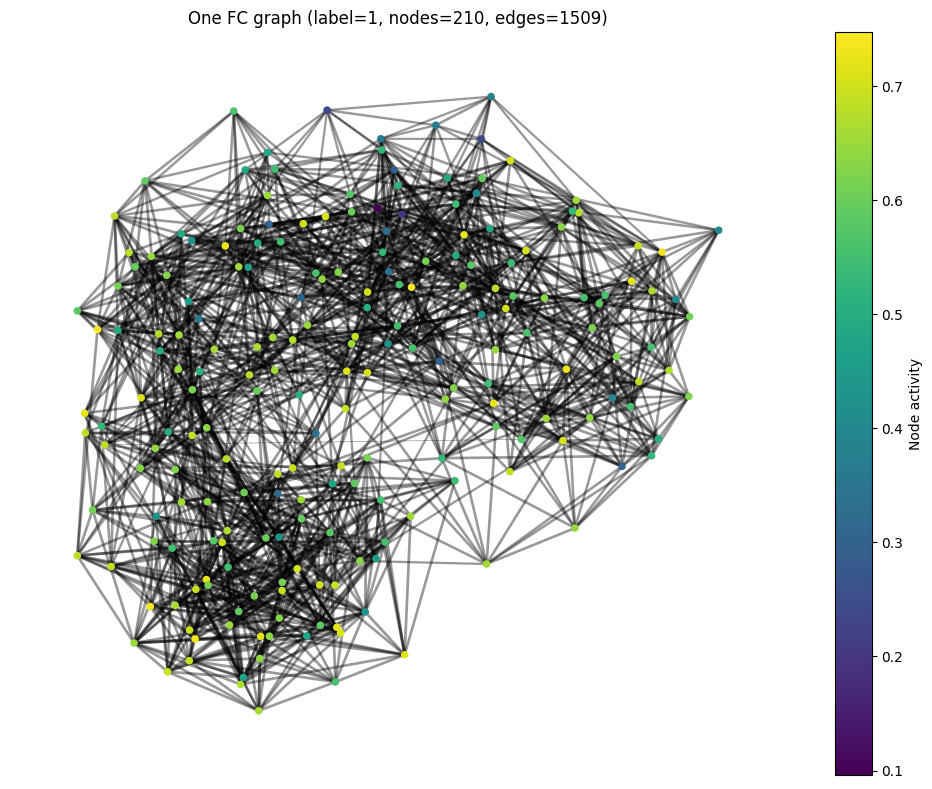

In [5]:
# visualizing first graph sample

graph_obj = dataset[0] # sub-01 sample
print("METADATA INFORMATION:")
print(f"subject: {graph_obj.subject}\nsubject's scan interval (60sec length): {graph_obj.interval}")

edge_index, edge_weights = graph_obj.edge_index, graph_obj.edge_attr # edge index shape as : (2, num_edges)

# networkx graph
G = nx.Graph()
for i in range(edge_index.shape[1]):
    u, v = int(edge_index[0, i].item()), int(edge_index[1, i].item())
    w = float(edge_weights[i].item())
    G.add_edge(u, v, weight=w)

# squeeze the unsqueezed from the Data object
node_vals = graph_obj.x.numpy().squeeze()  # activity = mean connectivity: lower purple, higher yellow

pos = nx.spring_layout(G, seed=42, k=0.5)
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx_nodes(G, pos, node_size=20, node_color=node_vals, cmap="viridis", ax=ax)
edges = G.edges()
weights = [G[u][v]["weight"] for u, v in edges]

# scale weights 
w_min, w_max = min(weights), max(weights)
widths = [0.5 + 1.5 * (w - w_min) / (w_max - w_min + 1e-8) for w in weights]
nx.draw_networkx_edges(G, pos, width=widths, alpha=0.4, ax=ax)
ax.set_title(f"One FC graph (label={graph_obj.y.item()}, nodes={G.number_of_nodes()}, edges={G.number_of_edges()})")
plt.axis("off")
plt.colorbar(plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(node_vals.min(), node_vals.max())), ax=ax, label="Node activity")
plt.tight_layout()
plt.show()

## Neural Network Construction
 
Some thoughts:
- Leave room for downstream/advanced analysis capabilities, ie. interpretability
    - "extract"/identify and isolate regions or clusters of regions that contribute significantly to classification decisions

In [ ]:
# prepare the data, 5-fold
dataset.shuffle()

dataset_size = len(dataset)
data_split = int(0.8 * dataset_size)

train_dataset = dataset[:data_split]
test_dataset = dataset[data_split:]

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

## Connectivity-Based Graph Convolutional Network
Test between cGCN ([paper](https://pmc.ncbi.nlm.nih.gov/articles/PMC7935029/)) and standard (PyG) GCN ([tutorial](https://colab.research.google.com/drive/1I8a0DfQ3fI7Njc62__mVXUlcAleUclnb?usp=sharing#scrollTo=0pq-VyzUwPpw))

In [7]:
class connectivityGCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        # Initialize MLPs used by EdgeConv layers
        self.mlp1 = Sequential(Linear(2 * dataset.num_node_features, hidden_channels), ReLU())
        self.mlp2 = Sequential(torch.nn.Linear(2 * hidden_channels, hidden_channels), ReLU())
        self.mlp3 = Sequential(torch.nn.Linear(2 * hidden_channels, hidden_channels), ReLU())

        # Initialize EdgeConv layers
        self.conv1 = EdgeConv(self.mlp1, aggr='max')
        self.conv2 = EdgeConv(self.mlp2, aggr='max')
        self.conv3 = EdgeConv(self.mlp3, aggr='max')

        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn3 = torch.nn.BatchNorm1d(hidden_channels)

        self.linear = torch.nn.Linear(hidden_channels, dataset.num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)

        x = global_mean_pool(x, batch)
        x = self.linear(x)
        x = F.softmax(x, dim=1)

        return x # softmax prob distribution

In [8]:
def train(model, loss_fn, device, data_loader, optimizer):
    """ Performs an epoch of model training.

    Parameters:
    model (nn.Module): Model to be trained.
    loss_fn (nn.Module): Loss function for training.
    device (torch.Device): Device used for training.
    data_loader (torch.utils.data.DataLoader): Data loader containing all batches.
    optimizer (torch.optim.Optimizer): Optimizer used to update model.

    Returns:
    float: Total loss for epoch.
    """
    model.train()
    loss = 0

    for batch in data_loader:
        batch = batch.to(device)

        optimizer.zero_grad()
        out = model(batch)

        loss = loss_fn(out, batch.y)

        loss.backward()
        optimizer.step()

    return loss.item()

def eval(model, device, loader):
    """ Calculate accuracy for all examples in a DataLoader.

    Parameters:
    model (nn.Module): Model to be evaluated.
    device (torch.Device): Device used for training.
    loader (torch.utils.data.DataLoader): DataLoader containing examples to test.
    """
    model.eval()
    cor = 0
    tot = 0

    for batch in loader:
        batch = batch.to(device)

        with torch.no_grad():
            pred = torch.argmax(model(batch), 1)

        y = batch.y
        cor += (pred == y).sum()
        tot += pred.shape[0]

    return cor / tot

Epoch: 01 | Loss: -0.5295 | Train: 59.56% | Test: 56.52%
Epoch: 02 | Loss: -0.6507 | Train: 59.56% | Test: 56.52%
Epoch: 03 | Loss: -0.6189 | Train: 59.56% | Test: 56.52%
Epoch: 04 | Loss: -0.4775 | Train: 59.56% | Test: 56.52%
Epoch: 05 | Loss: -0.5284 | Train: 59.56% | Test: 56.52%
Epoch: 06 | Loss: -0.4344 | Train: 59.56% | Test: 56.52%
Epoch: 07 | Loss: -0.6063 | Train: 57.92% | Test: 56.52%
Epoch: 08 | Loss: -0.5692 | Train: 58.47% | Test: 56.52%
Epoch: 09 | Loss: -0.6028 | Train: 57.38% | Test: 56.52%
Epoch: 10 | Loss: -0.7601 | Train: 59.02% | Test: 56.52%
Epoch: 11 | Loss: -0.5949 | Train: 59.02% | Test: 58.70%
Epoch: 12 | Loss: -0.4623 | Train: 59.56% | Test: 63.04%
Epoch: 13 | Loss: -0.6316 | Train: 62.84% | Test: 58.70%
Epoch: 14 | Loss: -0.6607 | Train: 65.03% | Test: 56.52%
Epoch: 15 | Loss: -0.7140 | Train: 61.75% | Test: 54.35%
Epoch: 16 | Loss: -0.5587 | Train: 63.93% | Test: 56.52%
Epoch: 17 | Loss: -0.7339 | Train: 62.30% | Test: 58.70%
Epoch: 18 | Loss: -0.6103 | Tra

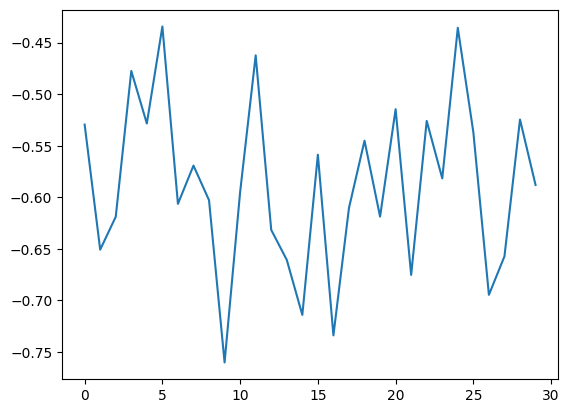

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = connectivityGCN(32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

loss_fn = torch.nn.NLLLoss()
losses = []

for epoch in range(0, 30):
    loss = train(model, loss_fn, device, train_loader, optimizer)
    train_result = eval(model, device, train_loader)
    test_result = eval(model, device, test_loader)

    losses.append(loss)

    print(f'Epoch: {epoch + 1:02d} | '
          f'Loss: {loss:.4f} | '
          f'Train: {100 * train_result:.2f}% | '
          f'Test: {100 * test_result:.2f}%')

plt.plot(losses)
plt.show()

In [11]:
# vanilla GCN from PyG
class GCN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.conv1 = GCNConv(dataset.num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, dataset.num_classes)

    def forward(self, x, edge_index, batch):
        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = global_mean_pool(x, batch)  # [batch_size, hidden_channels]

        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        
        return x

In [12]:
model = GCN(hidden_channels=64)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()

    for data in train_loader:  # Iterate in batches over the training dataset.
         out = model(data.x, data.edge_index, data.batch)  # Perform a single forward pass.
         loss = criterion(out, data.y)  # Compute the loss.
         loss.backward()  # Derive gradients.
         optimizer.step()  # Update parameters based on gradients.
         optimizer.zero_grad()  # Clear gradients.

def test(loader):
     model.eval()

     correct = 0
     for data in loader:  # Iterate in batches over the training/test dataset.
         out = model(data.x, data.edge_index, data.batch)  
         pred = out.argmax(dim=1)  # Use the class with highest probability.
         correct += int((pred == data.y).sum())  # Check against ground-truth labels.
     return correct / len(loader.dataset)  # Derive ratio of correct predictions.


for epoch in range(1, 171):
    train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    print(f'Epoch: {epoch:03d}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')

Epoch: 001, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 002, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 003, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 004, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 005, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 006, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 007, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 008, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 009, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 010, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 011, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 012, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 013, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 014, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 015, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 016, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 017, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 018, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 019, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 020, Train Acc: 0.5956, Test Acc: 0.5652
Epoch: 021, Train Acc: 0.5956, Test Acc: